## 1. Setup and Load Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model and data
xgb_model = joblib.load('churnsight_artifacts/xgb_model.pkl')
X_train = pd.read_csv('churnsight_artifacts/X_train.csv')
X_test = pd.read_csv('churnsight_artifacts/X_test.csv')
y_test = pd.read_csv('churnsight_artifacts/y_test.csv').squeeze()
feature_cols = joblib.load('churnsight_artifacts/feature_cols.pkl')

print(f"Model loaded: {type(xgb_model).__name__}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded: XGBClassifier
X_train: (5634, 44)
X_test: (1409, 44)
Features: 44


## 2. Initialize SHAP Explainer
Creating a TreeExplainer which is optimized specifically for XGBoost models.

In [2]:
# TreeExplainer is the correct explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f"Explainer type: {type(explainer).__name__}")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")

Explainer type: TreeExplainer
SHAP values shape: (1409, 44)
Expected value (base rate): -0.0155


## 3. Global Explainability
Understanding which features drive churn predictions across all customers.

### 3.1 SHAP Summary Plot (Bar)
Mean absolute SHAP values showing the most important features overall.

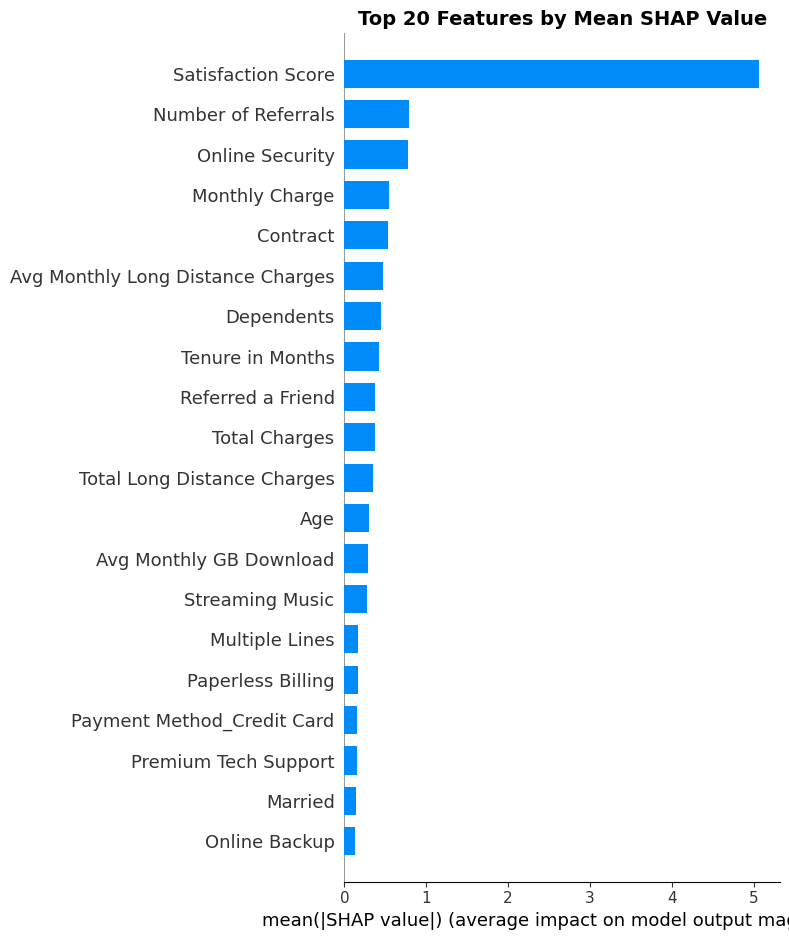

Top 10 Most Important Features:
                          Feature  Mean SHAP
               Satisfaction Score   5.067755
              Number of Referrals   0.794899
                  Online Security   0.782703
                   Monthly Charge   0.540533
                         Contract   0.534638
Avg Monthly Long Distance Charges   0.473692
                       Dependents   0.449830
                 Tenure in Months   0.425687
                Referred a Friend   0.380074
                    Total Charges   0.372432


In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Top 20 Features by Mean SHAP Value', 
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 numerically
mean_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean SHAP', ascending=False)

print("Top 10 Most Important Features:")
print(mean_shap.head(10).to_string(index=False))

> **Key Observations:**
> - **Satisfaction Score** dominates all other features with SHAP value of 5.07 - over 6x higher than second place
> - **Number of Referrals** and **Online Security** are second and third most important features
> - **Monthly Charge** and **Contract** confirm EDA findings as strong churn drivers
> - All top features are logically explainable making this a trustworthy model for business use

### 3.2 SHAP Summary Plot (Dot)
Shows direction and magnitude of each feature's impact on churn predictions.

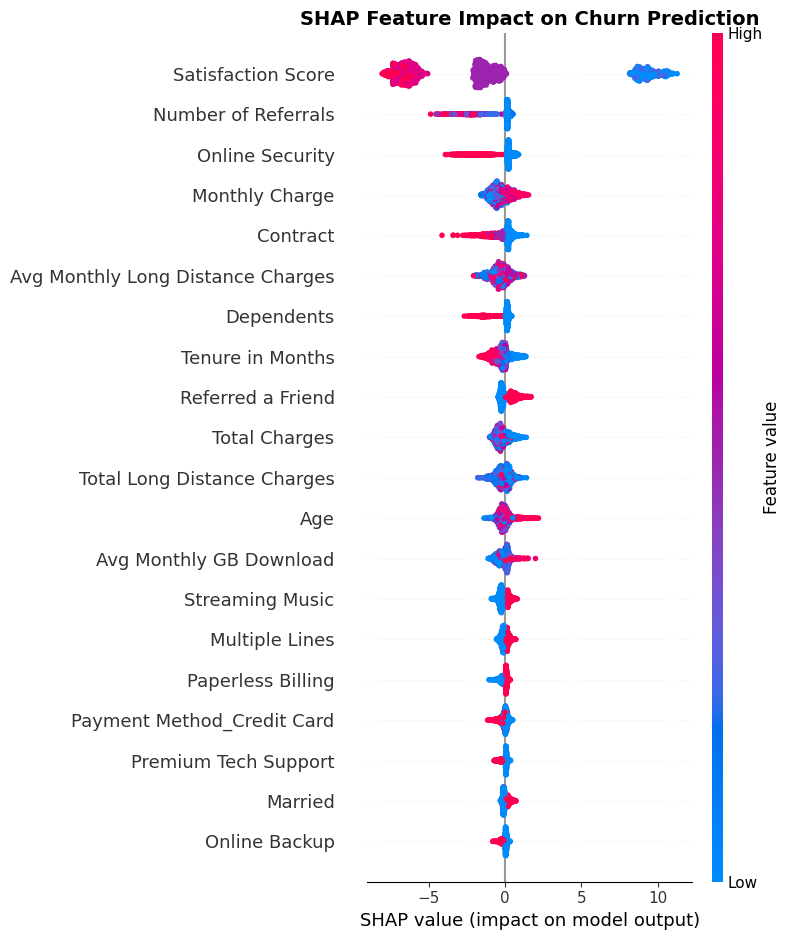

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Impact on Churn Prediction',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key Observations:**
> - **Satisfaction Score** shows the strongest and clearest directional pattern - low satisfaction (blue) pushes SHAP values as high as +12 toward churn
> - **Number of Referrals** and **Referred a Friend** both confirm that engaged customers who advocate for the brand are far less likely to churn
> - **Online Security** absence pushes customers toward churn - feeling unprotected drives switching
> - **Monthly Charge** high values push right - customers on expensive plans are more price-sensitive
> - **Tenure** low values push right - new customers in the first few months are the highest risk group

## 4. Local Explainability
Explaining individual customer predictions using SHAP waterfall plots.

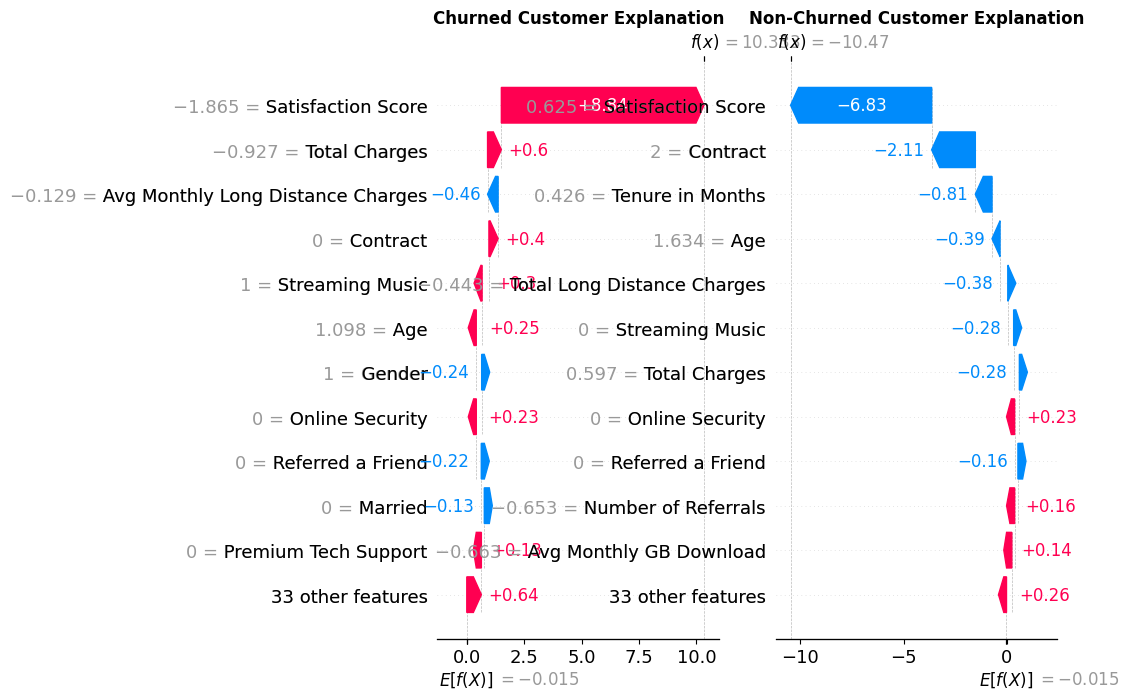

Churned customer prediction:     1
Not churned customer prediction: 0


In [5]:
# Pick one churned customer and one non-churned customer to explain
churned_idx = y_test[y_test == 1].index[0]
not_churned_idx = y_test[y_test == 0].index[0]

# Get their positions in X_test
churned_pos = X_test.index.get_loc(churned_idx)
not_churned_pos = X_test.index.get_loc(not_churned_idx)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Churned customer waterfall
plt.sca(axes[0])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churned_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[churned_pos],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
axes[0].set_title('Churned Customer Explanation', 
                   fontweight='bold', fontsize=12)

# Not churned customer waterfall
plt.sca(axes[1])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[not_churned_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[not_churned_pos],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
axes[1].set_title('Non-Churned Customer Explanation', 
                   fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churned customer prediction:     {xgb_model.predict(X_test.iloc[[churned_pos]])[0]}")
print(f"Not churned customer prediction: {xgb_model.predict(X_test.iloc[[not_churned_pos]])[0]}")

> **Local Explanation Insights:**
> - **Churned customer:** Low satisfaction score (0.625) contributed +8.54 SHAP value pushing strongly toward churn. Combined with Month-to-Month contract and short tenure the model correctly predicted churn (f(x) = +10.30)
> - **Non-churned customer:** High satisfaction score contributed -6.83 SHAP value pulling strongly away from churn. Two Year contract and longer tenure reinforced retention (f(x) = -10.47)
> - These individual explanations are what ChurnSight will display in the web app per customer

## 5. SHAP Dependence Plot
Showing how Satisfaction Score interacts with Contract type to influence churn.

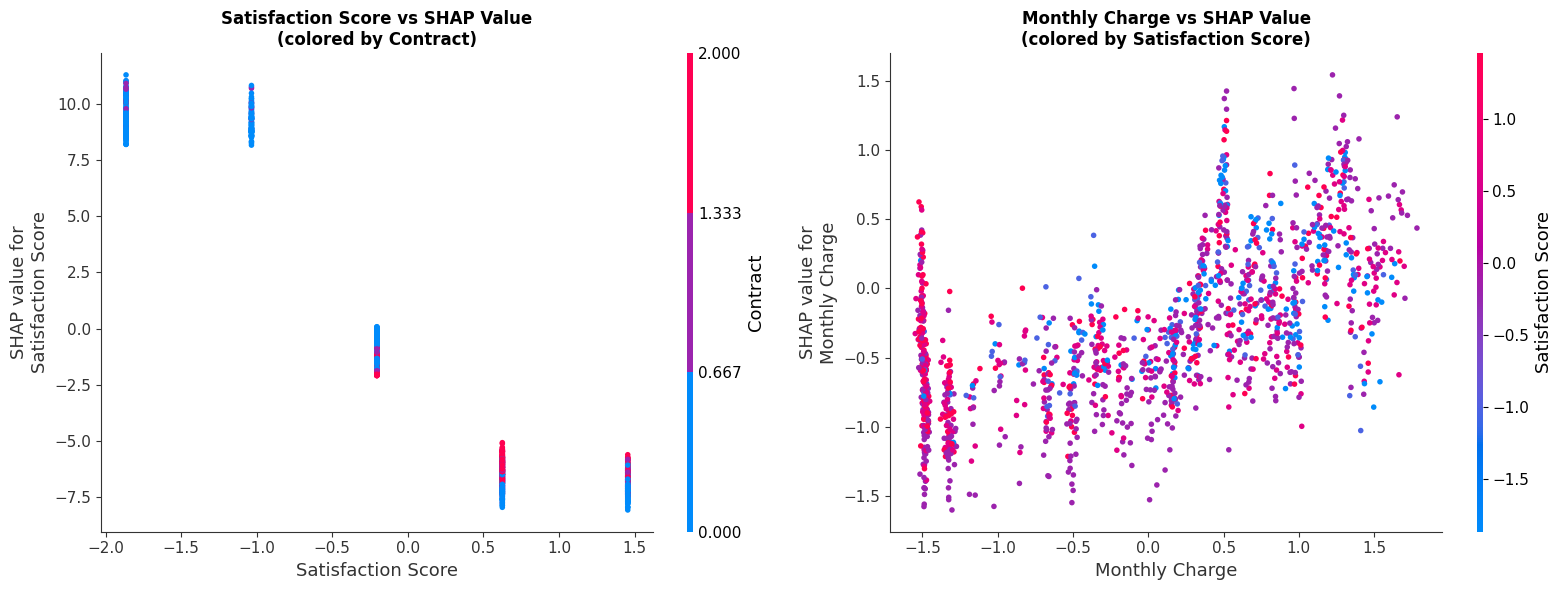

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Satisfaction Score dependence
plt.sca(axes[0])
shap.dependence_plot(
    'Satisfaction Score',
    shap_values,
    X_test,
    interaction_index='Contract',
    ax=axes[0],
    show=False
)
axes[0].set_title('Satisfaction Score vs SHAP Value\n(colored by Contract)',
                   fontweight='bold')

# Monthly Charge dependence
plt.sca(axes[1])
shap.dependence_plot(
    'Monthly Charge',
    shap_values,
    X_test,
    interaction_index='Satisfaction Score',
    ax=axes[1],
    show=False
)
axes[1].set_title('Monthly Charge vs SHAP Value\n(colored by Satisfaction Score)',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

> **Dependence Plot Insights:**
> - **Satisfaction Score** shows a perfectly monotonic relationship with churn risk - every step down in satisfaction score pushes SHAP value up by roughly 4 to 5 points
> - **Contract type** does not significantly moderate the satisfaction effect - satisfaction dominates regardless of contract length
> - **Monthly Charge** and **Satisfaction Score** interact - dissatisfied customers are more sensitive to price increases, making them a dual risk group for targeted retention

## 6. SHAP Explainability Summary

| Analysis | Key Finding |
|---|---|
| Global Bar Plot | Satisfaction Score is the dominant feature (SHAP 5.07), over 6x higher than second place |
| Global Dot Plot | Low satisfaction and short tenure push customers strongly toward churn |
| Local Waterfall - Churned | Satisfaction 0.625 contributed +8.54 SHAP value, combined with Month-to-Month contract |
| Local Waterfall - Retained | High satisfaction contributed -6.83 SHAP value, reinforced by Two Year contract |
| Dependence Plot | Dissatisfied customers are more price-sensitive, creating a dual churn risk |

**Next Stage:** Flask API Development